In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [17]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [18]:
dataset_path = os.getcwd()

In [19]:
print(os.listdir(dataset_path))

['group tomato project.ipynb', 'test.jfif', 'tomato_leaf_disease_model.keras', 'Tomato___Early_blight', 'Tomato___healthy']


In [20]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 1600 images belonging to 2 classes.
Found 400 images belonging to 2 classes.


In [7]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.7019 - loss: 0.5538 - val_accuracy: 0.8050 - val_loss: 0.3987
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.8906 - loss: 0.2674 - val_accuracy: 0.9200 - val_loss: 0.2062
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.9463 - loss: 0.1384 - val_accuracy: 0.9375 - val_loss: 0.1623
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.9625 - loss: 0.1071 - val_accuracy: 0.9350 - val_loss: 0.1884
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.9569 - loss: 0.1060 - val_accuracy: 0.9650 - val_loss: 0.1234
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.9750 - loss: 0.0699 - val_accuracy: 0.9475 - val_loss: 0.1631
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.9762 - loss: 0.0613 - val_accuracy: 0.9275 - val_loss: 0.1729
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 176s 3s/step - accuracy: 0.9831 - loss: 0.0446 - val_accuracy: 0.9600 - v

In [9]:
model.save("tomato_leaf_disease_model.keras")

print("Model saved successfully!")

Model saved successfully!


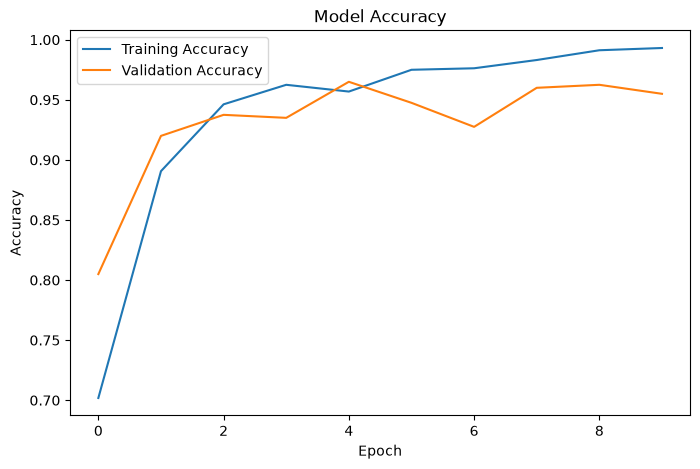

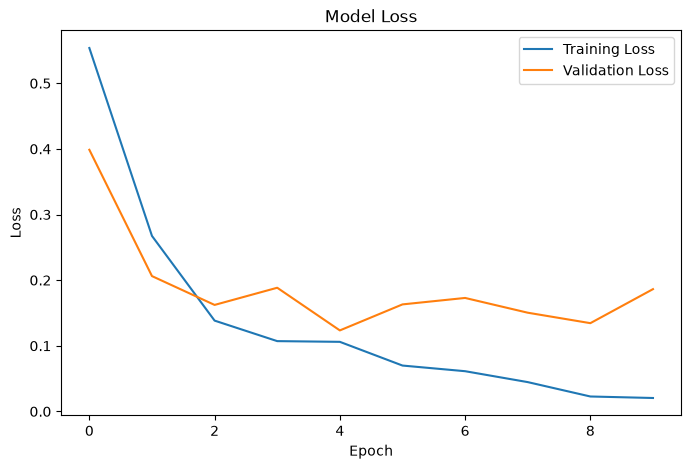

In [10]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [4]:
from tensorflow.keras.models import load_model

model = load_model("tomato_leaf_disease_model.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [10]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Load the test image
img = image.load_img("test.jfif", target_size=(128, 128))

# Convert image to array
img_array = image.img_to_array(img)

# Add one extra dimension for prediction
img_array = np.expand_dims(img_array, axis=0)

# Normalize the image
img_array = img_array / 255.0

# Make prediction
prediction = model.predict(img_array)

# Display the result
if prediction[0][0] > 0.5:
    print("Prediction: Tomato___healthy")
else:
    print("Prediction: Tomato___Early_blight")

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Prediction: Tomato___Early_blight


In [21]:
loss, accuracy = model.evaluate(validation_generator)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 533ms/step - accuracy: 0.9550 - loss: 0.1863
Validation Loss: 0.18631385266780853
Validation Accuracy: 0.9549999833106995


In [22]:
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 95.50%


In [23]:
print("The model correctly classified most tomato leaf images.")
print(f"Overall Accuracy: {accuracy*100:.2f}%")

The model correctly classified most tomato leaf images.
Overall Accuracy: 95.50%


In [24]:
print("Class Labels:")
print(train_generator.class_indices)

Class Labels:
{'Tomato___Early_blight': 0, 'Tomato___healthy': 1}


In [25]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("healthy_test.jpg", target_size=(128,128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Prediction: Healthy Tomato")
else:
    print("Prediction: Early Blight")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
Prediction: Early Blight


In [26]:
img = image.load_img("early_blight_test.jfif", target_size=(128,128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Prediction: Healthy Tomato")
else:
    print("Prediction: Early Blight")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
Prediction: Early Blight


In [27]:
print("========== MODEL EVALUATION ==========")
print(f"Validation Accuracy : {accuracy*100:.2f}%")
print(f"Validation Loss     : {loss:.4f}")
print("The model successfully distinguishes Healthy Tomato leaves from Tomato Early Blight.")
print("======================================")

========== MODEL EVALUATION ==========
Validation Accuracy : 95.50%
Validation Loss     : 0.1863
The model successfully distinguishes Healthy Tomato leaves from Tomato Early Blight.
